# 0. Problem statement

**Goal.** Predict the monthly **rental price** (`price`) using tabular attributes (e.g., `bedrooms`, `bathrooms`, `square_feet`, `cityname`, `state`) and free-text fields (`title`, `body`, optionally `amenities`, `address`).

**Why this matters.**
- Pricing guidance for owners and renters.
- Outlier detection (suspiciously cheap/expensive → potential fraud or data issues).
- Better ranking, search, and recommendations.

**Task.** Supervised **regression** (continuous target `price`).

**Caveats.**
- Right-skewed prices → log-transform often helps.
- Text is noisy/high-dimensional → TF-IDF with feature cap.
- Raw lat/long are not distances; scaling and non-linear models may help.
- Avoid leakage from display-like columns (e.g., `price_display`).


In [51]:
from pathlib import Path
import matplotlib.pyplot as plt  # fixed alias

def find_data_dir(start: Path) -> Path:
    """Search for a 'data/' folder by walking up from the current directory."""
    for p in [start, *start.parents]:
        d = p / "data"
        if d.exists():
            return d
    raise FileNotFoundError("Folder 'data/' not found. Open the project root or create 'data/'.")

DATA_ROOT = find_data_dir(Path.cwd())
cands = sorted(DATA_ROOT.rglob("*.csv"))
if not cands:
    raise FileNotFoundError("No CSV files found under data/. Please run ./scripts/get_data.sh")

# Prefer a CSV that contains '10k' in its path/name
c10k = [p for p in cands if "10k" in str(p).lower()]
CSV_PATH = c10k[0] if c10k else cands[0]

print("CSV_PATH:", CSV_PATH)
print("Exists:", CSV_PATH.exists(), "| Is file:", CSV_PATH.is_file())
print("Suffix:", CSV_PATH.suffix, "| Size (bytes):", CSV_PATH.stat().st_size)


CSV_PATH: /home/ivan/airbnb-la-2025/data/apartments_for_rent_classified_10K/apartments_for_rent_classified_10K.csv
Exists: True | Is file: True
Suffix: .csv | Size (bytes): 6309961
ERROR! Session/line number was not unique in database. History logging moved to new session 4


# 1. Data loading

The dataset lives under `data/.../apartments_for_rent_classified_10K.csv`.  
The delimiter is `;`. Several encodings are tried (`utf-8`, `cp1252`, `latin1`, …); malformed lines are skipped to keep the focus on modeling.


In [52]:
import pandas as pd

encodings = ["utf-8", "utf-8-sig", "cp1252", "latin1", "iso-8859-1"]
tried = []

df = None
for enc in encodings:
    # 1) python engine: tolerant, supports on_bad_lines
    try:
        df = pd.read_csv(
            CSV_PATH, sep=";", engine="python",
            encoding=enc, on_bad_lines="skip"
        )
        print(f"OK: sep=';', engine=python, encoding={enc}, shape={df.shape}")
        break
    except Exception as e:
        tried.append(("python", enc, type(e).__name__))

    # 2) C engine: fast, but no on_bad_lines
    try:
        df = pd.read_csv(
            CSV_PATH, sep=";", engine="c",
            encoding=enc
        )
        print(f"OK: sep=';', engine=c, encoding={enc}, shape={df.shape}")
        break
    except Exception as e:
        tried.append(("c", enc, type(e).__name__))

# 3) Final fallback: replace undecodable bytes
if df is None:
    df = pd.read_csv(
        CSV_PATH, sep=";", engine="python",
        encoding="latin1", encoding_errors="replace",
        on_bad_lines="skip"
    )
    print(f"FALLBACK: sep=';', engine=python, encoding=latin1+replace, shape={df.shape}")
    print("Attempts tried:", tried[:6])

print("\nSample rows:")
df.head(3)


OK: sep=';', engine=python, encoding=cp1252, shape=(10000, 22)

Sample rows:


,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,...,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410


# 3. Exploratory Data Analysis (EDA)

**Schema & health checks.**
- Inspect dtypes to separate numeric, categorical, and text features.
- Report missingness per column to plan imputation.

**Target distribution.**
- `price` is typically right-skewed → plot raw `price` and `log1p(price)`.

**Correlations.**
- Heatmap over numeric features (`bedrooms`, `bathrooms`, `square_feet`, `latitude`, `longitude`, `price`).
- Expect positive relation for size/rooms vs. price; lat/long often non-linear.

> Correlation ≠ causation; sensitive to outliers and missing-value handling.


In [53]:
from IPython.display import display

display(df.dtypes)
missing = (df.isna().mean() * 100).sort_values(ascending=False)
missing.head(15)



id                 int64
category          object
title             object
body              object
amenities         object
bathrooms        float64
bedrooms         float64
currency          object
fee               object
has_photo         object
pets_allowed      object
price              int64
price_display     object
price_type        object
square_feet        int64
address           object
cityname          object
state             object
latitude         float64
longitude        float64
source            object
time               int64
dtype: object

pets_allowed    41.63
amenities       35.49
address         33.27
cityname         0.77
state            0.77
bathrooms        0.34
latitude         0.10
longitude        0.10
bedrooms         0.07
category         0.00
title            0.00
body             0.00
id               0.00
fee              0.00
price_type       0.00
dtype: float64

In [54]:
# 1) Clean numeric-like columns from currency symbols, commas, spaces, etc.
def to_float(series):
    return (
        series.astype(str)
              .str.replace(r"[^\d\.\-]", "", regex=True)  # keep digits, dot, minus
              .replace({"": None})
              .astype(float)
    )

for c in ["price", "bathrooms", "bedrooms", "square_feet", "latitude", "longitude"]:
    if c in df.columns:
        df[c] = to_float(df[c])

# 2) Feature groups
all_cols = set(df.columns)

# numeric (target 'price' handled separately)
num_cols = [c for c in ["bathrooms", "bedrooms", "square_feet", "latitude", "longitude"] if c in all_cols]

# categorical (will be One-Hot encoded). fee/has_photo/pets_allowed are string markers → treat as categorical.
cat_cols = [c for c in [
    "category", "currency", "fee", "has_photo", "pets_allowed",
    "price_type", "cityname", "state", "source"
] if c in all_cols]

# text (free-form)
text_cols = [c for c in ["title", "body", "amenities", "address"] if c in all_cols]

target = "price"
assert target in df.columns, "Column 'price' is missing in the data"

print("num_cols:", num_cols)
print("cat_cols:", cat_cols)
print("text_cols:", text_cols)


num_cols: ['bathrooms', 'bedrooms', 'square_feet', 'latitude', 'longitude']
cat_cols: ['category', 'currency', 'fee', 'has_photo', 'pets_allowed', 'price_type', 'cityname', 'state', 'source']
text_cols: ['title', 'body', 'amenities', 'address']


# 4–6. Feature preparation

**Missing values.**
- Numeric: median imputation (robust to outliers).
- Categorical: most frequent imputation.
- Text: missing treated as empty strings before TF-IDF.

**Categorical encoding.**
- One-Hot Encoding with `handle_unknown="ignore"` for robust test-time behavior.

**Scaling.**
- Standardization on numeric features is crucial for KNN (distance-based).
- Text features are vectorized with TF-IDF (1–2 grams) and a feature cap to control runtime.


count    10000.000000
mean      1486.277500
std       1076.507968
min        200.000000
25%        949.000000
50%       1270.000000
75%       1695.000000
max      52500.000000
Name: price, dtype: float64

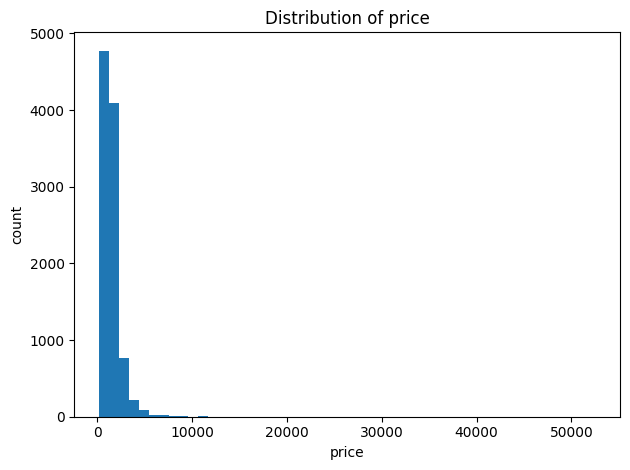

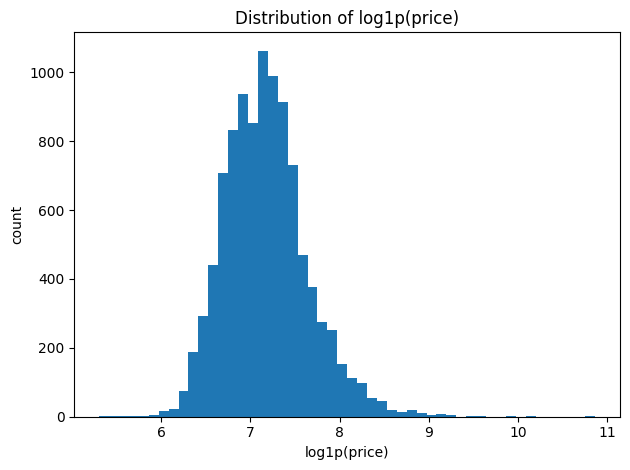

In [55]:
import numpy as np

# Target summary statistics
display(df[target].describe())

# Histograms: raw price and log-price (log smooths the right tail)
fig, ax = plt.subplots()
ax.hist(df[target].dropna(), bins=50)
ax.set_title("Distribution of price")
ax.set_xlabel("price")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.hist(np.log1p(df[target].dropna()), bins=50)
ax.set_title("Distribution of log1p(price)")
ax.set_xlabel("log1p(price)")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()


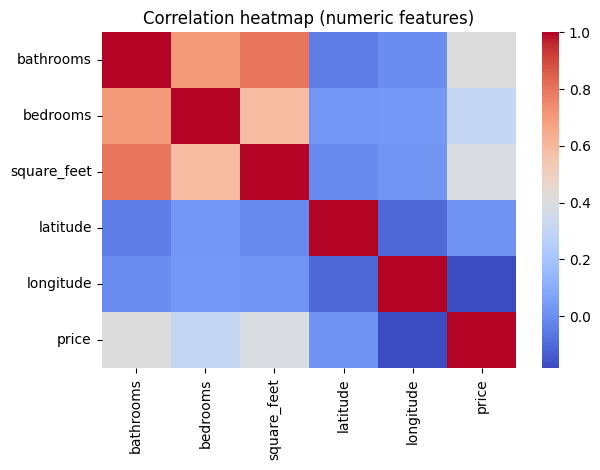

In [56]:
import seaborn as sns  # ensure sns is available

num_for_corr = [c for c in (num_cols + [target]) if c in df.columns]
if len(num_for_corr) >= 2:
    corr = df[num_for_corr].corr(numeric_only=True)
    plt.figure()
    sns.heatmap(corr, annot=False, cmap="coolwarm")
    plt.title("Correlation heatmap (numeric features)")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric features for a correlation heatmap — skipping.")


# 2. Train–test split

A single 80/20 hold-out split with `random_state=42` (reproducibility).  
Rows with missing `price` are dropped *before* splitting to avoid target leakage.


In [57]:
from sklearn.model_selection import train_test_split

target = "price"
before = len(df)
df = df[~df[target].isna()].copy()
print(f"Dropped {before - len(df)} rows with missing '{target}'. Remaining: {len(df)}")

X = df.drop(columns=[target])
y = df[target].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")


Dropped 0 rows with missing 'price'. Remaining: 10000
Train size: 8000 | Test size: 2000


In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix

def join_text(df_, cols):
    """Concatenate selected text columns into a single string per row."""
    if not cols:
        return pd.Series([""] * len(df_), index=df_.index)
    parts = [df_[c].fillna("").astype(str) for c in cols]
    return pd.Series((" ".join(row) for row in zip(*parts)), index=df_.index)

text_train = join_text(X_train, text_cols if 'text_cols' in globals() else [])
text_test  = join_text(X_test,  text_cols if 'text_cols' in globals() else [])

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_text_train = tfidf.fit_transform(text_train)
X_text_test  = tfidf.transform(text_test)

print("TF-IDF shapes:", X_text_train.shape, X_text_test.shape)


TF-IDF shapes: (8000, 3000) (2000, 3000)


# Building the design matrix

Two branches are prepared and then concatenated:
1) **Tabular pipeline** = impute → scale numeric → one-hot encode categoricals.  
2) **Text pipeline** = TF-IDF over concatenated free-text fields.

The final feature space is sparse: `X_*_all = [tabular | text]`.


In [59]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from scipy.sparse import hstack, issparse, csr_matrix

# Recover feature lists in case of a kernel restart
if 'num_cols' not in globals() or not num_cols:
    num_cols = [c for c in df.select_dtypes(include=['number']).columns if c != target]
if 'cat_cols' not in globals() or not cat_cols:
    cat_cols = [c for c in df.select_dtypes(include=['object']).columns]

num_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

table_tf = ColumnTransformer(
    transformers=[
        ("num", num_tf, [c for c in num_cols if c in X_train.columns]),
        ("cat", cat_tf, [c for c in cat_cols if c in X_train.columns]),
    ],
    remainder="drop"
)

# Fit/transform tabular branch
X_table_train = table_tf.fit_transform(X_train)
X_table_test  = table_tf.transform(X_test)

# Ensure sparse before hstack with TF-IDF
if not issparse(X_table_train):
    X_table_train = csr_matrix(X_table_train)
if not issparse(X_table_test):
    X_table_test = csr_matrix(X_table_test)

# Final design matrices: [tabular | text]
X_train_all = hstack([X_table_train, X_text_train])
X_test_all  = hstack([X_table_test,  X_text_test])

print("Final shapes:", X_train_all.shape, X_test_all.shape)


Final shapes: (8000, 4496) (2000, 4496)


# 7. Baseline model: KNN regression

**Why KNN.**
- Non-parametric and simple; sensitive to scaling (handled above).

**Hyperparameters.**
- `n_neighbors` (bias–variance trade-off),
- `weights` (`uniform` vs. `distance`),
- `p` (Minkowski distance: 1 = Manhattan, 2 = Euclidean).

**Protocol.** 3-fold CV with MAE; best configuration is refit on the full training set and evaluated on the hold-out test set.

**Metrics.**
- **MAE** (interpretable, currency units),
- **RMSE** (penalizes large errors),
- **R²** (explained variance).


In [60]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

knn = KNeighborsRegressor()

param_grid = {
    "n_neighbors": [3, 5, 7, 11, 15],
    "weights": ["uniform", "distance"],
    "p": [1, 2]  # 1 = Manhattan, 2 = Euclidean
}

grid = GridSearchCV(
    knn,
    param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    refit=True,
    verbose=0
)
grid.fit(X_train_all, y_train)

print("Best params:", grid.best_params_)
print("CV-MAE:", -grid.best_score_)


Best params: {'n_neighbors': 5, 'p': 2, 'weights': 'distance'}
CV-MAE: 303.87833859956146


# 8. Error analysis: residual diagnostics

- **Residuals vs predicted**: checks heteroscedasticity or systematic bias.  
- **Residual histogram**: should be centered near zero; heavy tails indicate outliers or underfitting.

If a clear pattern is visible, consider log-target training, feature engineering, or a more flexible model.


In [61]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor

best = grid.best_estimator_ if 'grid' in globals() else None

# Fallback in case GridSearch was skipped
if best is None:
    print("GridSearch was not run — using a default KNN for reporting.")
    best = KNeighborsRegressor(n_neighbors=7, weights='distance', p=2)
    best.fit(X_train_all, y_train)

def report(model, Xtr, ytr, Xte, yte, name="Model"):
    pred_tr = model.predict(Xtr)
    pred_te = model.predict(Xte)
    for split, y_true, y_pred in [("Train", ytr, pred_tr), ("Test", yte, pred_te)]:
        mae  = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2   = r2_score(y_true, y_pred)
        print(f"{name} | {split}:  MAE={mae:.2f}  RMSE={rmse:.2f}  R2={r2:.3f}")

report(best, X_train_all, y_train, X_test_all, y_test, name="KNN")


KNN | Train:  MAE=0.03  RMSE=1.12  R2=1.000
KNN | Test:  MAE=282.67  RMSE=551.71  R2=0.658


# 9. Linear baselines: Ridge and Lasso

- **Ridge (L2)** reduces variance while keeping all coefficients.  
- **Lasso (L1)** induces sparsity, which is useful with many weak TF-IDF features.

Both are trained on the combined (tabular + text) feature set to benchmark against KNN.


In [62]:
from sklearn.linear_model import RidgeCV, LassoCV
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define a small reporting helper if it is not already available
if 'print_regression_report' not in globals():
    def print_regression_report(y_true_tr, y_pred_tr, y_true_te, y_pred_te, name="Model"):
        def _m(y_true, y_pred):
            mae  = mean_absolute_error(y_true, y_pred)
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            r2   = r2_score(y_true, y_pred)
            return mae, rmse, r2
        mae_tr, rmse_tr, r2_tr = _m(y_true_tr, y_pred_tr)
        mae_te, rmse_te, r2_te = _m(y_true_te, y_pred_te)
        print(f"{name} | Train: MAE={mae_tr:.2f} RMSE={rmse_tr:.2f} R2={r2_tr:.3f}")
        print(f"{name} | Test : MAE={mae_te:.2f} RMSE={rmse_te:.2f} R2={r2_te:.3f}")

# Ridge (linear baseline)
ridge = RidgeCV(alphas=[0.1, 1.0, 3.0, 10.0], cv=3)
ridge.fit(X_train_all, y_train)
pred_tr_ridge = ridge.predict(X_train_all)
pred_te_ridge = ridge.predict(X_test_all)
print_regression_report(y_train, pred_tr_ridge, y_test, pred_te_ridge, name="Ridge")

# Lasso (sparse linear baseline)
lasso = LassoCV(alphas=[0.001, 0.003, 0.01, 0.03, 0.1], cv=3, max_iter=5000)
lasso.fit(X_train_all, y_train)
pred_tr_lasso = lasso.predict(X_train_all)
pred_te_lasso = lasso.predict(X_test_all)
print_regression_report(y_train, pred_tr_lasso, y_test, pred_te_lasso, name="Lasso")



Ridge | Train: MAE=259.17 RMSE=576.57 R2=0.729
Ridge | Test : MAE=314.82 RMSE=955.03 R2=-0.025


/home/ivan/airbnb-la-2025/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.330e+08, tolerance: 4.663e+05
  model = cd_fast.sparse_enet_coordinate_descent(
/home/ivan/airbnb-la-2025/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.581e+08, tolerance: 4.663e+05
  model = cd_fast.sparse_enet_coordinate_descent(
/home/ivan/airbnb-la-2025/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or 

Lasso | Train: MAE=254.87 RMSE=426.32 R2=0.852
Lasso | Test : MAE=309.26 RMSE=869.89 R2=0.149


# 9′. Tree baseline (tabular only): RandomForest

A RandomForest is trained on **tabular features only** (no TF-IDF) via a separate preprocessing pipeline:
- Numeric: median imputation (scaling optional for trees).
- Categorical: ordinal encoding (compact when categories are many).

This provides a non-linear, interaction-aware baseline.


In [63]:
# === RandomForest on tabular features only (no TF-IDF) ===
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Safety in case of kernel restart: rebuild lists
if 'num_cols' not in globals() or not num_cols:
    num_cols = [c for c in df.select_dtypes(include=['number']).columns if c != 'price']
if 'cat_cols' not in globals() or not cat_cols:
    cat_cols = [c for c in df.select_dtypes(include=['object']).columns]

num_tf_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())  # not required for trees, but harmless
])

cat_tf_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

table_tf_rf = ColumnTransformer(
    transformers=[
        ("num", num_tf_rf, [c for c in num_cols if c in X_train.columns]),
        ("cat", cat_tf_rf, [c for c in cat_cols if c in X_train.columns]),
    ],
    remainder="drop"
)

rf = Pipeline([
    ("prep", table_tf_rf),
    ("rf", RandomForestRegressor(
        n_estimators=300, random_state=42, n_jobs=-1,
        max_depth=None, min_samples_leaf=1
    ))
])

rf.fit(X_train, y_train)
pred_tr_rf = rf.predict(X_train)
pred_te_rf = rf.predict(X_test)

def print_regression_report(y_true_tr, y_pred_tr, y_true_te, y_pred_te, name="Model"):
    import numpy as np
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    def _m(y_true, y_pred):
        mae  = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2   = r2_score(y_true, y_pred)
        return mae, rmse, r2
    mae_tr, rmse_tr, r2_tr = _m(y_true_tr, y_pred_tr)
    mae_te, rmse_te, r2_te = _m(y_true_te, y_pred_te)
    print(f"{name} | Train: MAE={mae_tr:.2f} RMSE={rmse_tr:.2f} R2={r2_tr:.3f}")
    print(f"{name} | Test : MAE={mae_te:.2f} RMSE={rmse_te:.2f} R2={r2_te:.3f}")

print_regression_report(y_train, pred_tr_rf, y_test, pred_te_rf, name="RandomForest (table-only)")



RandomForest (table-only) | Train: MAE=106.23 RMSE=295.65 R2=0.929
RandomForest (table-only) | Test : MAE=258.84 RMSE=484.25 R2=0.736


# 8′. Unified test metrics & model comparison

We compare **MAE**, **RMSE**, and **R²** on the same test split for:
- KNN (grid-searched baseline),
- KNN (log-target, fast CV),
- Ridge,
- Lasso,
- RandomForest (tabular-only).

The best model by **MAE** is highlighted; residuals for that model are visualized.


In [64]:
# Unified test metrics & comparison table
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def metrics_df(y_true, y_pred, label):
    return pd.DataFrame([{
        "model": label,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }])

rows = []

# Collect only models that were actually computed
if 'best' in globals() and best is not None:
    rows.append(metrics_df(y_test, best.predict(X_test_all), "KNN (base)"))

if 'pred_te_log' in globals():
    rows.append(metrics_df(y_test, pred_te_log, "KNN (log-target)"))

if 'pred_te_ridge' in globals():
    rows.append(metrics_df(y_test, pred_te_ridge, "Ridge"))

if 'pred_te_lasso' in globals():
    rows.append(metrics_df(y_test, pred_te_lasso, "Lasso"))

if 'pred_te_rf' in globals():
    rows.append(metrics_df(y_test, pred_te_rf, "RandomForest (table)"))

summary = pd.concat(rows, ignore_index=True).sort_values("MAE")
summary.reset_index(drop=True, inplace=True)
display(summary)

,model,MAE,RMSE,R2
0,RandomForest (table),258.839029,484.252421,0.736399
1,KNN (log-target),274.417083,545.822296,0.665107
2,KNN (base),282.671853,551.705517,0.657849
3,Lasso,309.262716,869.886596,0.149395
4,Ridge,314.815528,955.029169,-0.025265


Best by MAE: RandomForest (table)


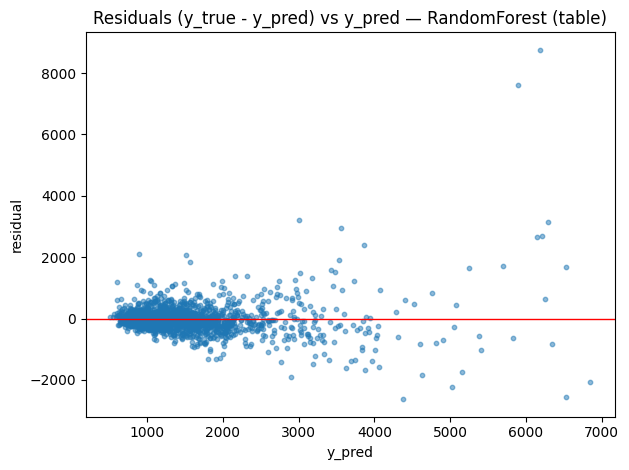

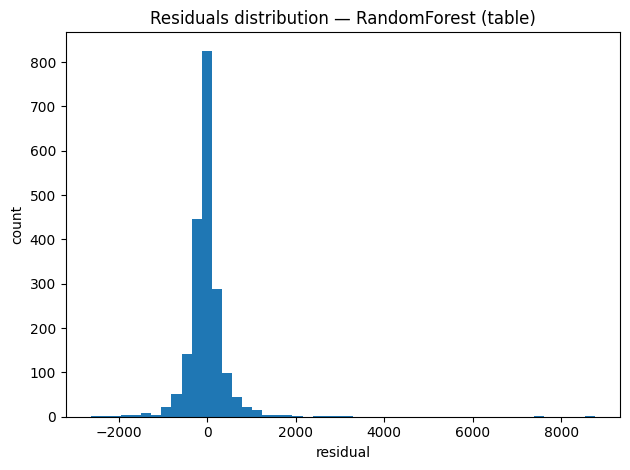

In [65]:
# Residual diagnostics for the best model by MAE (after summary)
best_row = summary.iloc[0]
best_label = best_row["model"]
print(f"Best by MAE: {best_label}")

# build a safe map of predictions that actually exist
pred_best_map = {}
if 'best' in globals() and best is not None:
    pred_best_map["KNN (base)"] = best.predict(X_test_all)
if 'pred_te_log' in globals():
    pred_best_map["KNN (log-target)"] = pred_te_log
if 'pred_te_ridge' in globals():
    pred_best_map["Ridge"] = pred_te_ridge
if 'pred_te_lasso' in globals():
    pred_best_map["Lasso"] = pred_te_lasso
if 'pred_te_rf' in globals():
    pred_best_map["RandomForest (table)"] = pred_te_rf

y_pred_best = pred_best_map[best_label]
resid_best = y_test - y_pred_best

fig, ax = plt.subplots()
ax.scatter(y_pred_best, resid_best, s=10, alpha=0.5)
ax.axhline(0, color="red", lw=1)
ax.set_title(f"Residuals (y_true - y_pred) vs y_pred — {best_label}")
ax.set_xlabel("y_pred")
ax.set_ylabel("residual")
plt.tight_layout()
plt.show()

plt.figure()
plt.hist(resid_best, bins=50)
plt.title(f"Residuals distribution — {best_label}")
plt.xlabel("residual")
plt.ylabel("count")
plt.tight_layout()
plt.show()


# 11. (Optional) Dropping highly correlated numeric features

Highly collinear numeric features can inflate variance and degrade some models.  
We flag features with |corr| > 0.95 and (optionally) drop them, then refit pipelines and models.


In [66]:
# (Optional) flag highly correlated numeric features
corr_thr = 0.95
num_for_corr = [c for c in num_cols if c in df.columns]
cm = df[num_for_corr].corr(numeric_only=True).abs()
to_drop = set()
for i, c1 in enumerate(num_for_corr):
    for c2 in num_for_corr[i+1:]:
        if cm.loc[c1, c2] > corr_thr:
            to_drop.add(c2)

print(f"Highly correlated numeric features (|corr| > {corr_thr}):", to_drop)

# If you actually want to drop and refit, uncomment and rebuild the pipelines:
# X = X.drop(columns=list(to_drop), errors="ignore")
# X_train = X_train.drop(columns=list(to_drop), errors="ignore")
# X_test = X_test.drop(columns=list(to_drop), errors="ignore")
# (then rebuild table_tf, X_table_*, and X_*_all)


Highly correlated numeric features (|corr| > 0.95): set()


# 12. Conclusions

**Best model (by MAE).**  
_Fill in with your actual results from the summary table._  
Example: “The best MAE on the test set is achieved by **<model>** with **MAE = <...>**, **RMSE = <...>**, **R² = <...>**.”

**Key takeaways.**
- Proper **scaling** and **imputation** are essential for distance-based models like KNN.  
- **Text features** (TF-IDF) add useful signal beyond tabular metadata.  
- Linear baselines (Ridge/Lasso) are competitive and interpretable; RandomForest captures interactions without text.

**Limitations.**
- No geography-specific feature engineering (e.g., H3 grid, distance to CBD).  
- No explicit outlier filtering or deduplication.  
- Lat/long used raw; better spatial encoding may help.

**Next steps.**
- Location features (H3 clustering, distance engineering).  
- Text normalization (currency symbols, promotions).  
- More model families (Gradient Boosting: XGBoost/LightGBM; target encoding for categoricals; stacking).
